In [1]:
pip install pandas nltk scikit-learn matplotlib seaborn wordcloud

In [5]:
# Download required NLTK data (Updated to fix Colab error)
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')  # Fixes the LookupError for tokenization
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Dataset successfully created and saved as 'coretech_feedback.csv'

--- Sample of Processed Data ---
                                       Feedback_Text  \
0  The cloud hosting service is exceptionally rel...   
1  Support was very slow to respond to our critic...   
2  Data analytics dashboards are okay, but they l...   
3  The AI consultation completely transformed our...   
4  The custom software delivered had too many bug...   

                                        Clean_Tokens  
0  [cloud, hosting, service, exceptionally, relia...  
1  [support, slow, respond, critical, cybersecuri...  
2  [data, analytics, dashboard, okay, lack, advan...  
3  [ai, consultation, completely, transformed, au...  
4  [custom, software, delivered, many, bug, delay...   

TF-IDF Matrix Shape: (31, 162) (Documents, Unique Words)



/tmp/ipykernel_2244/3759613635.py:138: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sentiment', data=df, palette='viridis', order=['Positive', 'Neutral', 'Negative'])


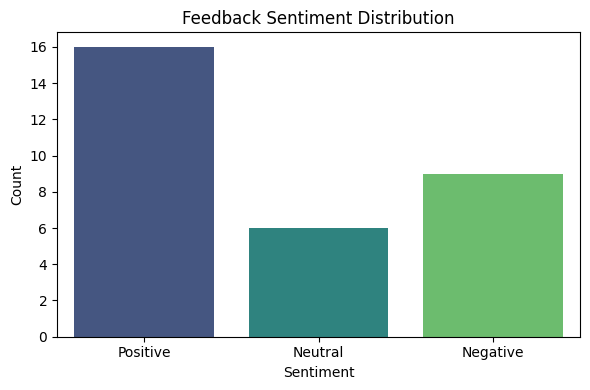

Saved 'sentiment_distribution.png'


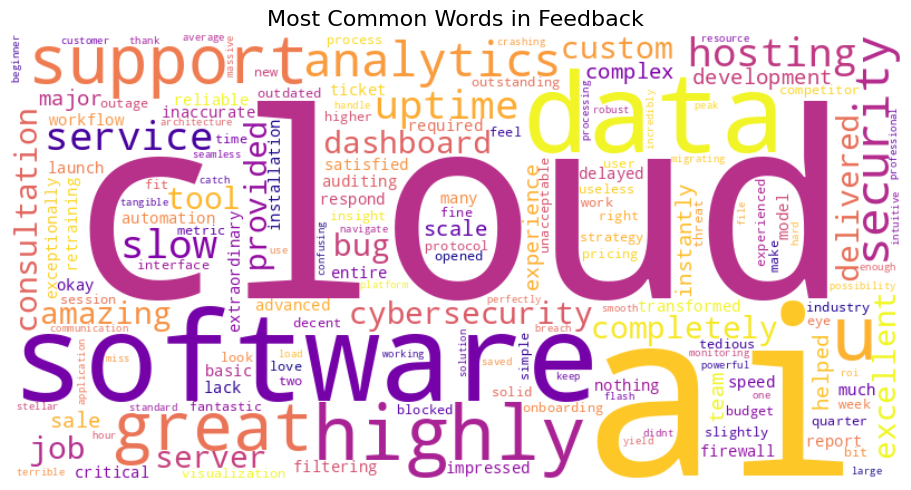

Saved 'feedback_wordcloud.png'

--- Naive Bayes Classification Report ---
Accuracy: 57.14%

              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00         2
     Neutral       0.00      0.00      0.00         1
    Positive       0.57      1.00      0.73         4

    accuracy                           0.57         7
   macro avg       0.19      0.33      0.24         7
weighted avg       0.33      0.57      0.42         7



In [6]:
import os
import re
import string
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Pehle wordcloud install karlein agar install nahi hai
try:
    from wordcloud import WordCloud
except ImportError:
    import os
    os.system('pip install wordcloud')
    from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

# --- FIX: Download all required NLTK data (Added 'omw-1.4') ---
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# ---------------------------------------------------------
# 1. Create the Synthetic Feedback Dataset (>= 30 rows)
# ---------------------------------------------------------
data = {
    "Feedback_ID": [f"FB_{i:03d}" for i in range(1, 32)],
    "Client_Name": [
        "Acme Corp", "TechNova", "Global Industries", "Quantum Labs", "Apex Solutions",
        "Beta Systems", "Delta Media", "Echo Logistics", "Omega Foods", "Zeta Energy",
        "Alpha FinTech", "Horizon IT", "Vanguard Group", "Starlight Inc", "Summit Corp",
        "Matrix Group", "Nexus Ltd", "Infinity Co", "Pinnacle Soft", "Vertex Ltd",
        "Catalyst Co", "Titanium Labs", "Meridian Corp", "Solstice Inc", "Radiant Tech",
        "Nova Retail", "Pulse Media", "Prism Solutions", "Core Tech", "Stratford Group",
        "Dynamic Systems"
    ],
    "Service": [
        "Cloud Hosting", "Cybersecurity", "Data Analytics", "AI Consultation", "Custom Software",
        "Cloud Hosting", "Cybersecurity", "Data Analytics", "AI Consultation", "Custom Software",
        "Cloud Hosting", "Cybersecurity", "Data Analytics", "AI Consultation", "Custom Software",
        "Cloud Hosting", "Cybersecurity", "Data Analytics", "AI Consultation", "Custom Software",
        "Cloud Hosting", "Cybersecurity", "Data Analytics", "AI Consultation", "Custom Software",
        "Cloud Hosting", "Cybersecurity", "Data Analytics", "AI Consultation", "Custom Software",
        "Cloud Hosting"
    ],
    "Feedback_Text": [
        "The cloud hosting service is exceptionally reliable and has great uptime!",
        "Support was very slow to respond to our critical cybersecurity ticket.",
        "Data analytics dashboards are okay, but they lack advanced filtering tools.",
        "The AI consultation completely transformed our automation workflow. Amazing!",
        "The custom software delivered had too many bugs and delayed our entire launch.",
        "Excellent uptime on the cloud servers, very satisfied with the speed.",
        "Highly impressed with the firewall installation and security auditing.",
        "The reports are basic. It does the job but nothing extraordinary.",
        "The AI models provided were highly inaccurate and required too much retraining.",
        "Outstanding custom software development! Delivered right on time and budget.",
        "Decent cloud hosting, but the pricing is slightly higher than competitors.",
        "Fantastic cybersecurity team! They blocked a major threat instantly.",
        "The data insights helped us scale our sales by 20% this quarter. Great job!",
        "The AI consultation was completely useless and did not fit our industry.",
        "Software works fine, but the user interface feels a bit outdated.",
        "We experienced two major server outages this week. Unacceptable service.",
        "Security protocols are solid, but the onboarding process is tedious.",
        "Love the data visualizations! It makes complex metrics look simple.",
        "The AI strategy session opened our eyes to amazing new possibilities.",
        "Terrible experience. The software keeps crashing during peak hours.",
        "Migrating to their cloud was seamless and customer support was stellar.",
        "Average security monitoring. They catch standard bugs but miss complex ones.",
        "The analytics platform is incredibly slow when processing large files.",
        "Great experience working with the AI team. Highly professional.",
        "The software architecture is robust and handles our load perfectly.",
        "The cloud dashboard is confusing and hard to navigate for beginners.",
        "They saved us from a massive data breach. Cannot thank them enough!",
        "Analytics tools are powerful and highly intuitive to use.",
        "The AI solution provided didn't yield any tangible ROI for us.",
        "The application development was smooth and communication was excellent.",
        "Cloud support helped us scale resources instantly during our flash sale."
    ],
    "Rating": [5, 2, 3, 5, 1, 5, 5, 3, 2, 5, 3, 5, 5, 1, 3, 1, 3, 5, 5, 1, 5, 3, 2, 5, 5, 2, 5, 5, 2, 5, 5],
    "Sentiment": [
        "Positive", "Negative", "Neutral", "Positive", "Negative",
        "Positive", "Positive", "Neutral", "Negative", "Positive",
        "Neutral", "Positive", "Positive", "Negative", "Neutral",
        "Negative", "Neutral", "Positive", "Positive", "Negative",
        "Positive", "Neutral", "Negative", "Positive", "Positive",
        "Negative", "Positive", "Positive", "Negative", "Positive",
        "Positive"
    ]
}

df = pd.DataFrame(data)
csv_filename = "coretech_feedback.csv"
df.to_csv(csv_filename, index=False)
print(f"Dataset successfully created and saved as '{csv_filename}'\n")

# ---------------------------------------------------------
# 2. Text Preprocessing Pipeline
# ---------------------------------------------------------
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_and_tokenize(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = word_tokenize(text)
    cleaned_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return cleaned_tokens

# Apply preprocessing
df['Clean_Tokens'] = df['Feedback_Text'].apply(clean_and_tokenize)
df['Clean_Text'] = df['Clean_Tokens'].apply(lambda x: ' '.join(x))

print("--- Sample of Processed Data ---")
print(df[['Feedback_Text', 'Clean_Tokens']].head(), "\n")

# ---------------------------------------------------------
# 3. TF-IDF Vectorization
# ---------------------------------------------------------
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(df['Clean_Text'])
print(f"TF-IDF Matrix Shape: {tfidf_matrix.shape} (Documents, Unique Words)\n")

# ---------------------------------------------------------
# 4. Visualizations (With plt.show() for Colab)
# ---------------------------------------------------------
# Chart 1: Sentiment Distribution Chart
plt.figure(figsize=(6, 4))
sns.countplot(x='Sentiment', data=df, palette='viridis', order=['Positive', 'Neutral', 'Negative'])
plt.title('Feedback Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('sentiment_distribution.png')
plt.show()  # Colab mein dekhne ke liye
plt.close()
print("Saved 'sentiment_distribution.png'")

# Chart 2: Word Cloud of Most Common Words
all_words = ' '.join(df['Clean_Text'])
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='plasma').generate(all_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Feedback', fontsize=16)
plt.tight_layout()
plt.savefig('feedback_wordcloud.png')
plt.show()  # Colab mein dekhne ke liye
plt.close()
print("Saved 'feedback_wordcloud.png'\n")

# ---------------------------------------------------------
# 5. Basic Sentiment Classification using Naive Bayes
# ---------------------------------------------------------
X = tfidf_matrix
y = df['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

nb_classifier = MultinomialNB()
nb_classifier.fit(X_train, y_train)

y_pred = nb_classifier.predict(X_test)

print("--- Naive Bayes Classification Report ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}\n")
print(classification_report(y_test, y_pred, zero_division=0))